# **Sparse coding: Matheo Madrid** #

### **Importamos librerias que vamos a utilizar:**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import seaborn as sns # Necesario para la función sns.heatmap()

from datetime import datetime
from meteostat import Point, Daily
from sklearn.decomposition import DictionaryLearning
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

### **Extraemos los datos metereológicos:**

In [8]:
# ==========================================
# 1) EXTRACCIÓN MASIVA DE DATOS (34 AÑOS)
# ==========================================
print("Conectando a bases de datos globales (NOAA/OMM)...")

# Coordenadas de Madrid (Latitud, Longitud, Altitud)
ubicacion = Point(40.4168, -3.7038, 667)

# Definimos el periodo: 34 años (1990 - 2023)
inicio = datetime(1990, 1, 1)
fin = datetime(2023, 12, 31)

# Descargamos los datos diarios
datos_brutos = Daily(ubicacion, inicio, fin).fetch()

print(f"Datos crudos descargados: {datos_brutos.shape[0]} días.")

Conectando a bases de datos globales (NOAA/OMM)...
Datos crudos descargados: 12418 días.


### **Preparamos las series temporales:**

#### Inspección de Valores Nulos (NaN)

Antes de transformar o rellenar nuestra serie temporal, es fundamental saber la calidad de los datos crudos y comprobar si existen valores faltantes (`NaN`).

**¿Por qué es crítico este paso?**
El algoritmo del **Sparse Coding** (al igual que la gran mayoría de técnicas de *Machine Learning*) requiere matrices puramente numéricas para funcionar. Su aprendizaje se basa en operaciones complejas de álgebra lineal; por tanto, la presencia de un solo valor `NaN` (Not a Number) en los 34 años de registros rompería los cálculos matemáticos y haría que el modelo fallara inmediatamente.

A continuación, vamos a contabilizar exactamente cuántos días carecen de mediciones y en qué variables físicas ocurren. Esto nos permitirá decidir si es seguro aplicar técnicas de relleno (como la interpolación, o tomar el mismo valor del dia anterior o posterior) o si los huecos son tan grandes que requieren descartar ciertos periodos.

In [9]:
# ==========================================
# INSPECCIÓN DE DATOS FALTANTES ANTES DE RELLENAR
# ==========================================
# 1. Ver el total de huecos por cada variable física
print("Recuento de valores faltantes por columna:")
print(datos_limpios.isnull().sum())
print("-" * 60)

# 2. Filtrar y guardar solo los días que tienen al menos un hueco
dias_con_nulos = datos_limpios[datos_limpios.isnull().any(axis=1)]

print(f"Total de días que tienen algún dato en blanco: {len(dias_con_nulos)} de {len(datos_limpios)}")

# 3. Imprimir los primeros 20 días conflictivos para ojearlos
print("\nMuestra de los días con huecos:")
print(dias_con_nulos.head(20))
print("-" * 60)

Recuento de valores faltantes por columna:
tavg    0
tmin    0
tmax    0
prcp    0
wspd    0
dtype: int64
------------------------------------------------------------
Total de días que tienen algún dato en blanco: 0 de 12418

Muestra de los días con huecos:
Empty DataFrame
Columns: [tavg, tmin, tmax, prcp, wspd]
Index: []
------------------------------------------------------------


#### Limpieza Preventiva y Preparación Matemática de la Serie Temporal

Aunque nuestra inspección previa nos haya revelado una matriz perfecta sin valores nulos, un código de *Machine Learning* robusto debe estar preparado para cualquier eventualidad. Si en el futuro cambiamos las coordenadas a una estación meteorológica menos constante, o si la base de datos de origen se actualiza con nuevos huecos, este bloque de código actuará como un mecanismo de seguridad automático.

Aquí aplicamos tres filtros de preprocesamiento fundamentales antes de inyectar los datos en el algoritmo:

1. **Filtro de fiabilidad (Umbral del 70%):** Si un sensor ha estado estropeado o inactivo más del 30% del tiempo durante estas tres décadas, eliminamos esa dimensión por completo para evitar que el modelo aprenda sobre "ruido" o datos artificiales.
2. **Imputación de valores faltantes (Relleno de huecos):** Para los días sueltos en los que un sensor pudo haber fallado, aplicamos técnicas de reconstrucción. Se puede optar por arrastrar el último valor válido conocido (`ffill`), o utilizar una **interpolación lineal**, que calcula matemáticamente el punto medio entre el día anterior y el posterior (ideal para variables climáticas continuas).
3. **Aislamiento de la matriz numérica:** El *Sparse Coding* requiere álgebra lineal pura. En este último paso, separamos exclusivamente las columnas métricas (aislándolas de fechas o metadatos) para construir la matriz final que procesará el modelo.

In [ ]:
# ==========================================
# 2) LIMPIEZA Y PREPARACIÓN DE SERIES TEMPORALES LARGAS
# ==========================================
umbral_validos = int(len(datos_brutos) * 0.70)  # Si una columna tiene menos del 70% de datos reales se elimina
datos_limpios = datos_brutos.dropna(axis=1, thresh=umbral_validos)
datos_limpios = datos_limpios.ffill().bfill() # Se rellenan huecos con valores posteriores y anteriores
# Una alternativa al ffill es usar la interpolación lineal, que puede ser más precisa para datos meteorológicos. 
##      datos_limpios = datos_limpios.interpolate().bfill()

# Extraemos la matriz puramente matemática
X_raw = datos_limpios.select_dtypes(include=[np.number])# Nos quedamos con las columnas métricas (tª, humedad, etc, no fechas)
nombres_variables = X_raw.columns.tolist()  # Se enumeran las columnas
dias_totales = X_raw.shape[0]  # Se definen dimensiones
dimension_real = X_raw.shape[1]

print("-" * 60)
print(f"Matriz consolidada: {dias_totales} días válidos con {dimension_real} dimensiones físicas.")
print("-" * 60)

------------------------------------------------------------
Matriz consolidada: 12418 días válidos con 5 dimensiones físicas.
------------------------------------------------------------


### **Separamos el dataset en *training* y *test*:**

In [32]:
# ==========================================
# 3) SEPARACIÓN DEL PASADO HISTÓRICO (TRAIN) Y LA ÚLTIMA DÉCADA (TEST):
# ==========================================
corte = int(dias_totales * 0.70)  # Se usa el 70% de datos para predecir el último 30%
X_train_raw = X_raw.iloc[:corte]  # El antes y el después
X_test_raw = X_raw.iloc[corte:]

scaler = StandardScaler()   # Normalización de todas las variables: se invoca la función
X_train_scaled = scaler.fit_transform(X_train_raw)   # Normalización de los datos de entrenamiento (se halla media y desviación estándar)
X_test_scaled = scaler.transform(X_test_raw)    # Normalización de los datos de prueba (se aplica la media y desviación estándar del entrenamiento)

print(f"Días de Entrenamiento (Pasado histórico): {X_train_scaled.shape[0]}")
print(f"Días de Prueba (La última década):        {X_test_scaled.shape[0]}")
print("-" * 60)

Días de Entrenamiento (Pasado histórico): 8692
Días de Prueba (La última década):        3726
------------------------------------------------------------


### **Iniciamos el aprendizaje del diccionario:**

In [45]:
# ==========================================
# 4) ENTRENAMIENTO DEL DICCIONARIO (CON CRONÓMETRO)
# ==========================================
n_atoms = 40

print(f"Entrenando {n_atoms} átomos históricos usando el pasado (Train)...")

dict_learner = DictionaryLearning(
    n_components=n_atoms, 
    alpha=1.0, 
    transform_algorithm='lasso_lars', 
    random_state=42,
    max_iter=1000,
    n_jobs=-1  # Exprime todos los núcleos del ordenador al máximo
)

# Iniciamos el cronómetro
inicio_tiempo = time.time()

# Entrenamos el modelo EXCLUSIVAMENTE con el pasado (X_train_scaled)
dict_learner.fit(X_train_scaled)
dictionary_atoms = dict_learner.components_

# Paramos el cronómetro
fin_tiempo = time.time()
tiempo_ejecucion = fin_tiempo - inicio_tiempo
print(f"¡Entrenamiento completado en {tiempo_ejecucion:.2f} segundos!")
print("-" * 60)

Entrenando 40 átomos históricos usando el pasado (Train)...
¡Entrenamiento completado en 38.34 segundos!
------------------------------------------------------------


### **Visualizamos los átomos:**


Generando el catálogo de micro-climas (Grupos de 5)...


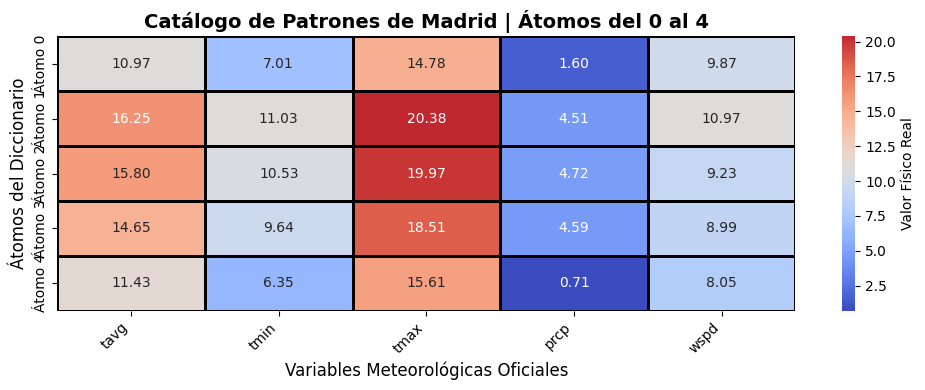

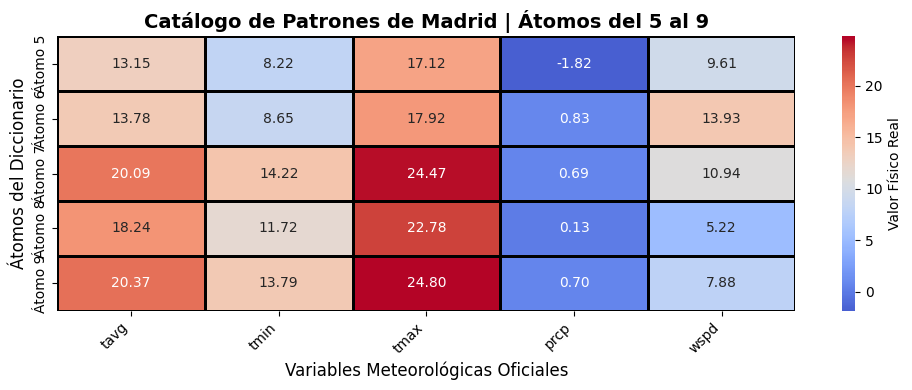

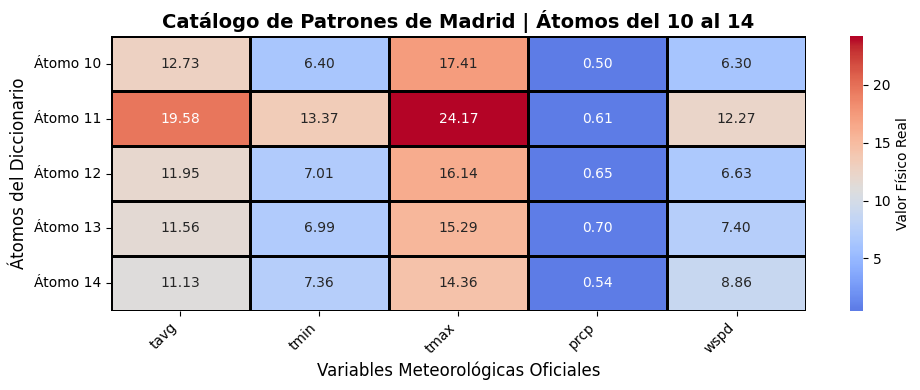

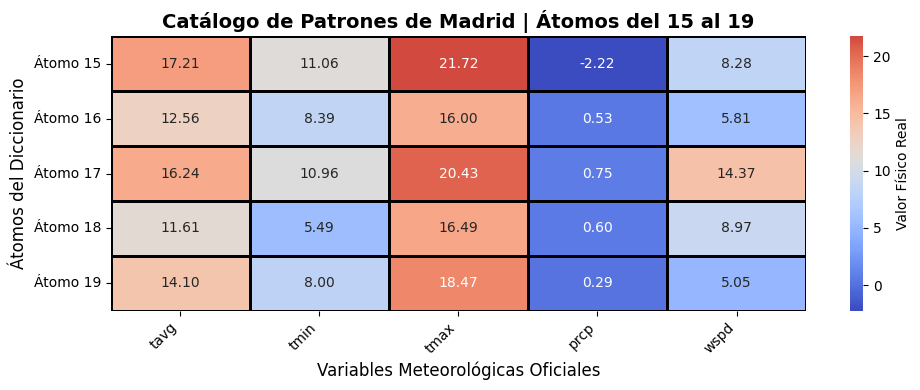

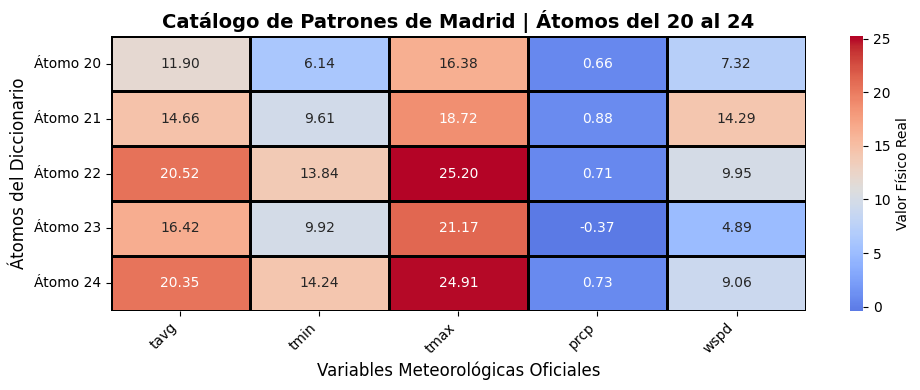

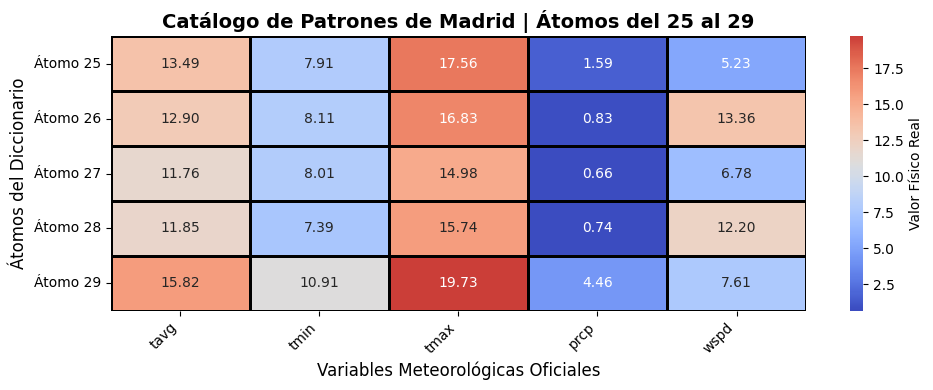

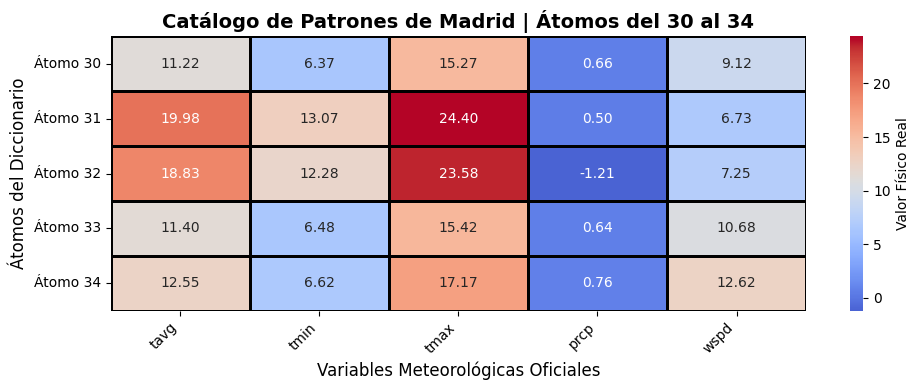

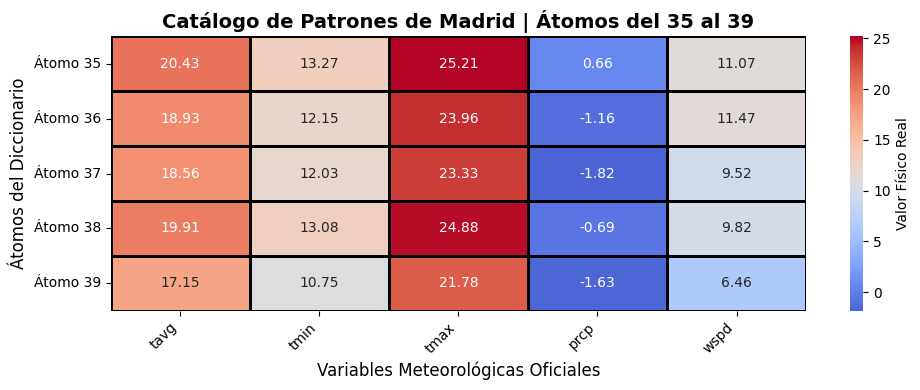

In [46]:
# ==========================================
# 5) BUCLE DE VISUALIZACIÓN (DE 5 EN 5)
# ==========================================
print("\nGenerando el catálogo de micro-climas (Grupos de 5)...")

# Deshacemos el escalado usando el 'scaler' ajustado en el bloque 3
atomos_reales = scaler.inverse_transform(dictionary_atoms)
df_atomos_reales = pd.DataFrame(atomos_reales, columns=nombres_variables)
df_atomos_reales.index = [f"Átomo {i}" for i in range(n_atoms)]

# Valor central para que la escala de colores tenga sentido físico
centro_color = df_atomos_reales.mean().mean()

# Bucle mágico que salta de 5 en 5
for i in range(0, 40, 5):
    # Extraemos el "trozo" de 5 átomos
    df_chunk = df_atomos_reales.iloc[i : i+5]
    
    # Creamos una figura nueva para cada trozo
    plt.figure(figsize=(10, 4))
    
    sns.heatmap(df_chunk, annot=True, fmt=".2f", cmap="coolwarm", center=centro_color,
                linewidths=1, linecolor='black', cbar_kws={'label': 'Valor Físico Real'})
    
    plt.title(f"Catálogo de Patrones de Madrid | Átomos del {i} al {i+4}", fontsize=14, fontweight='bold')
    plt.xlabel("Variables Meteorológicas Oficiales", fontsize=12)
    plt.ylabel("Átomos del Diccionario", fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    
    # Imprimimos cada imagen por separado
    plt.show()

#### **Veamos información de nuestro diccionario aprendido:**

In [47]:
# ==========================================
# 5) EVALUACIÓN EXACTA
# ==========================================
# MSE exacto puro, respetando la regla matemática
mse_test_exacto = mean_squared_error(X_test_scaled, X_test_reconstructed)

# Cálculo de la esparcidad (porcentaje de ceros en la matriz)
ceros_exactos = np.sum(np.abs(sparse_test) < 1e-5)
esparcidad_test = (ceros_exactos / sparse_test.size) * 100

# Error del Sparse Coding (Función de Coste Objetivo exacta)
# Suma del error de reconstrucción puro + penalización L1 (esparcidad)
error_reconstruccion_sum = 0.5 * np.sum((X_test_scaled - X_test_reconstructed) ** 2)
penalizacion_l1 = dict_learner.alpha * np.sum(np.abs(sparse_test))
error_sparse_coding = error_reconstruccion_sum + penalizacion_l1

print("\n" + "="*60)
print(" RESULTADOS EXACTOS SOBRE 3 DÉCADAS")
print("="*60)
print(f" Tiempo de entrenamiento CPU:           {tiempo_ejecucion:.2f} segundos")
print(f" MSE Exacto en la última década (Test): {mse_test_exacto:.4f}")
print(f" Error de Sparse Coding (Coste Total):  {error_sparse_coding:.4f}")
print(f" Esparcidad sostenida:                  {esparcidad_test:.2f}% de ceros")
print("="*60)


 RESULTADOS EXACTOS SOBRE 3 DÉCADAS
 Tiempo de entrenamiento CPU:           38.34 segundos
 MSE Exacto en la última década (Test): 0.2018
 Error de Sparse Coding (Coste Total):  5944.2821
 Esparcidad sostenida:                  96.20% de ceros


### **PARTE DE *TEST* DEL DATASET: REAL vs. RECONSTRUÍDA**

Generando gráficas individuales para las 5 variables físicas...


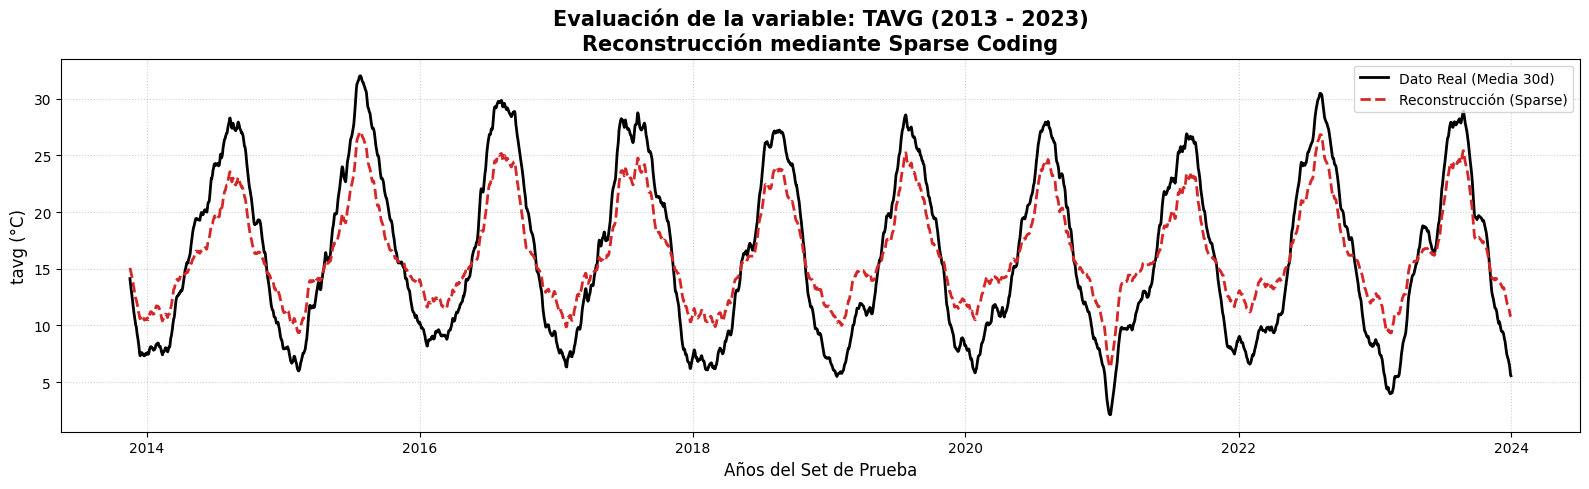

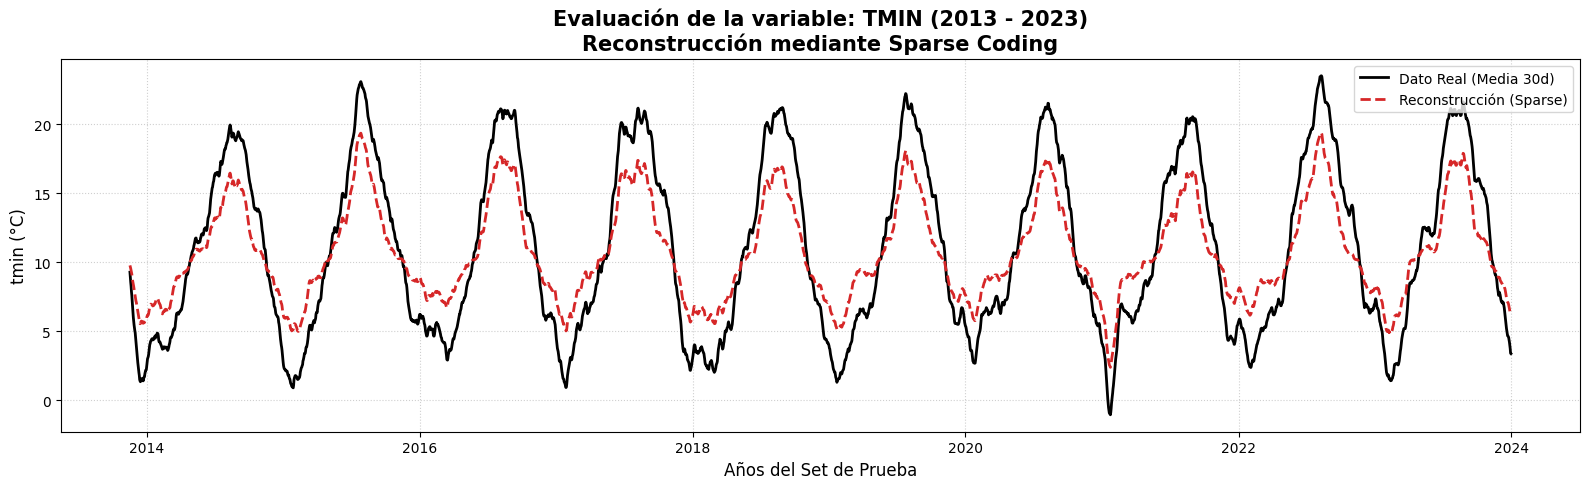

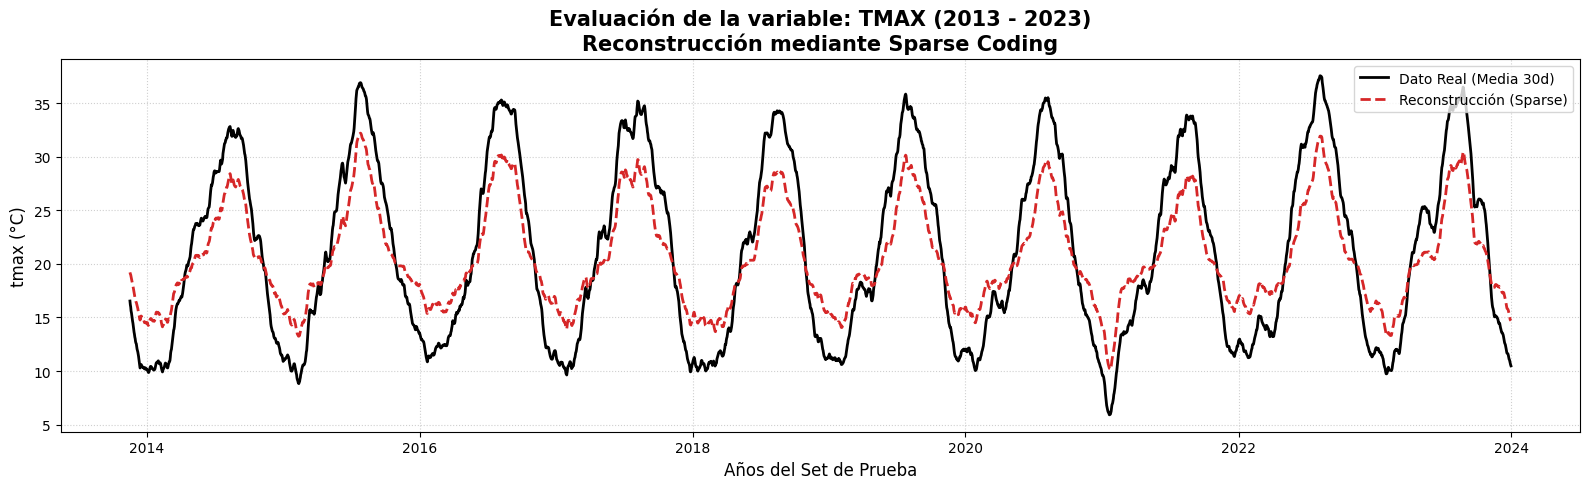

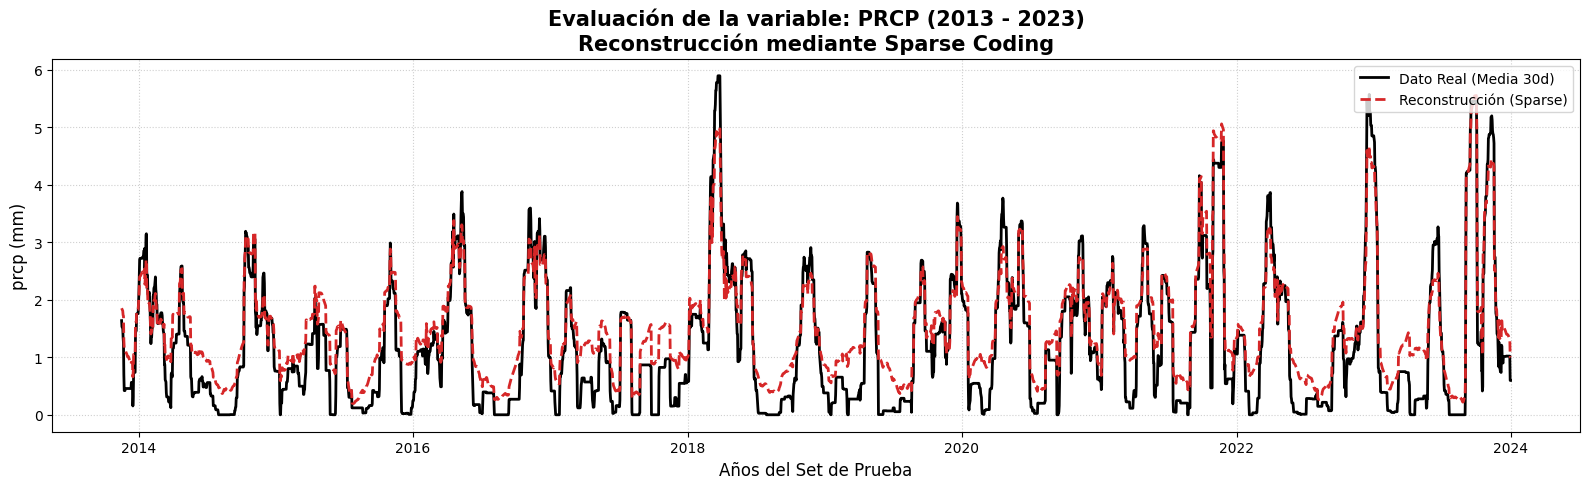

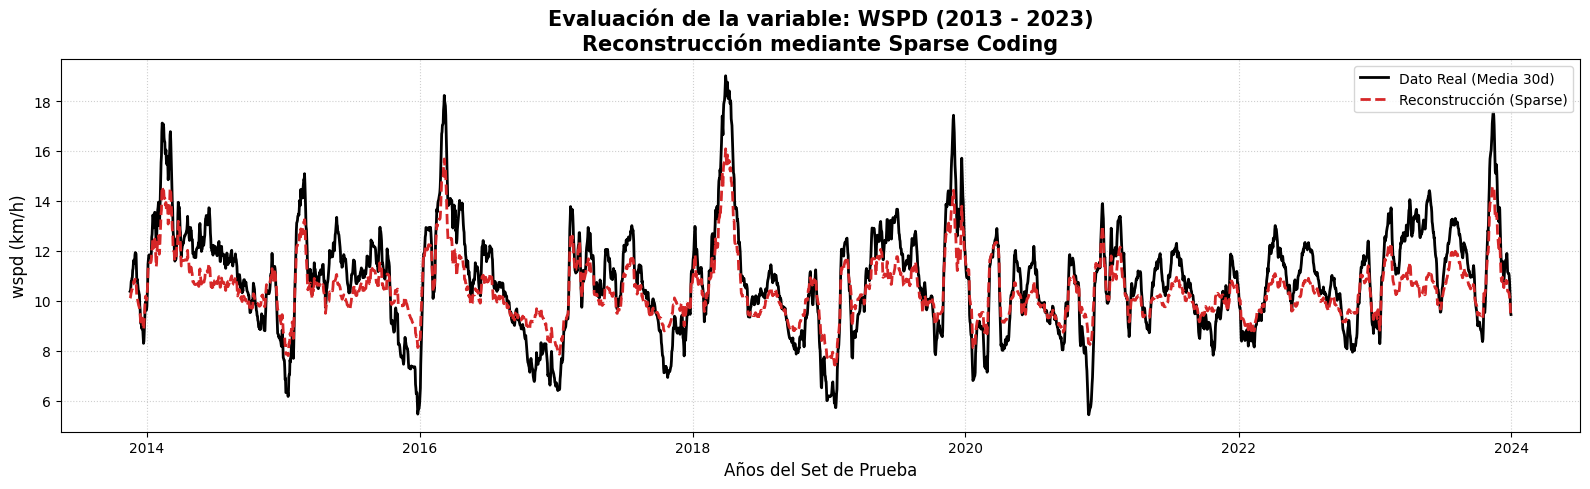

In [48]:
# ==========================================
# 6) GRÁFICA MULTIVARIABLE: RECONSTRUCCIÓN INDIVIDUAL (TEST)
# ==========================================
print("Generando gráficas individuales para las 5 variables físicas...")

# 1. Deshacemos el escalado de TODA la matriz (Test real y Test reconstruido)
test_real_fisico = scaler.inverse_transform(X_test_scaled)
test_recon_fisico = scaler.inverse_transform(X_test_reconstructed)

# 2. Extraemos fechas exactas y años para el título
fechas_test = X_test_raw.index
año_inicio = fechas_test.year.min()
año_fin = fechas_test.year.max()

# 3. Diccionario de unidades para que los ejes Y sean perfectos
unidades = {'tavg': '°C', 'tmin': '°C', 'tmax': '°C', 'prcp': 'mm', 'wspd': 'km/h'}

# 4. Bucle mágico: dibuja e imprime una gráfica independiente por cada variable
for i, variable in enumerate(nombres_variables):
    
    # Extraemos la serie temporal de la variable 'i'
    serie_real = pd.Series(test_real_fisico[:, i], index=fechas_test)
    serie_recon = pd.Series(test_recon_fisico[:, i], index=fechas_test)
    
    # Suavizamos los datos (media móvil de 30 días)
    real_suavizado = serie_real.rolling(window=30).mean()
    recon_suavizado = serie_recon.rolling(window=30).mean()
    
    # CREAMOS UNA FIGURA NUEVA EN CADA VUELTA DEL BUCLE
    plt.figure(figsize=(16, 5))
    
    # Pintamos las líneas
    plt.plot(real_suavizado.index, real_suavizado, color='black', label='Dato Real (Media 30d)', linewidth=2)
    plt.plot(recon_suavizado.index, recon_suavizado, color='tab:red', label='Reconstrucción (Sparse)', linestyle='--', linewidth=2)
    
    # Formato de la gráfica actual
    unidad = unidades.get(variable, 'Valor')
    plt.title(f'Evaluación de la variable: {variable.upper()} ({año_inicio} - {año_fin})\nReconstrucción mediante Sparse Coding', fontsize=15, fontweight='bold')
    plt.ylabel(f'{variable} ({unidad})', fontsize=12)
    plt.xlabel('Años del Set de Prueba', fontsize=12)
    plt.legend(loc="upper right")
    plt.grid(True, linestyle=':', alpha=0.6)
    
    plt.tight_layout()
    
    # AL ESTAR DENTRO DEL BUCLE, IMPRIME LA IMAGEN Y PASA A LA SIGUIENTE
    plt.show()

#### Veamos ahora está grafica pero por años:

Generando radiografía detallada para el año 2023...


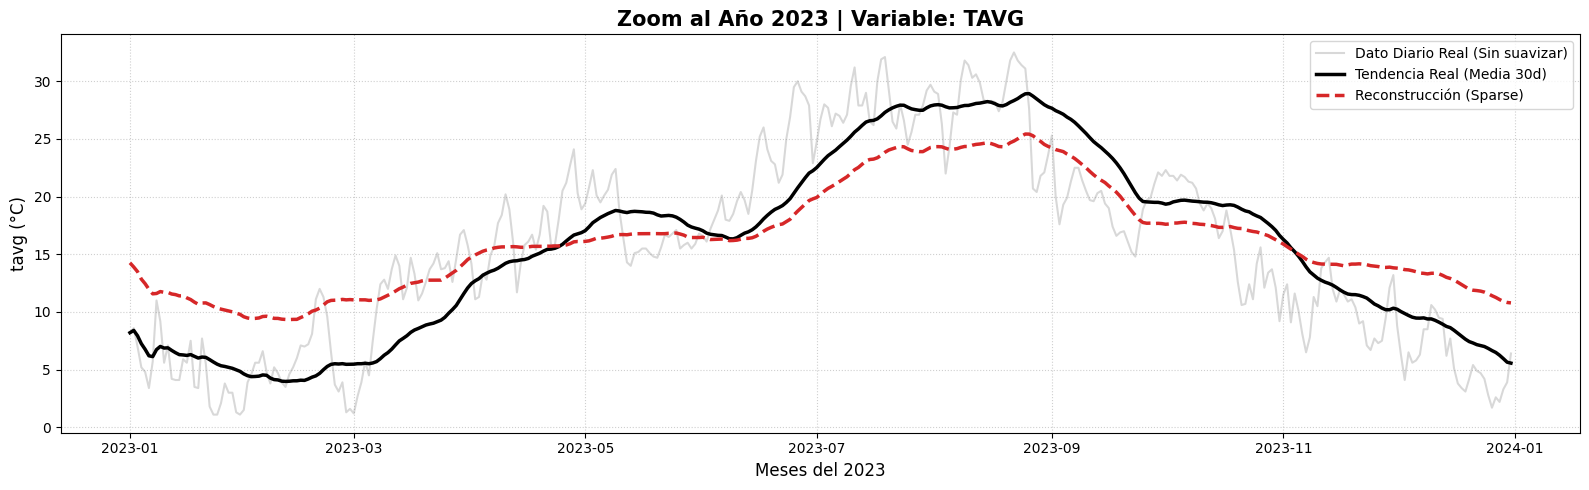

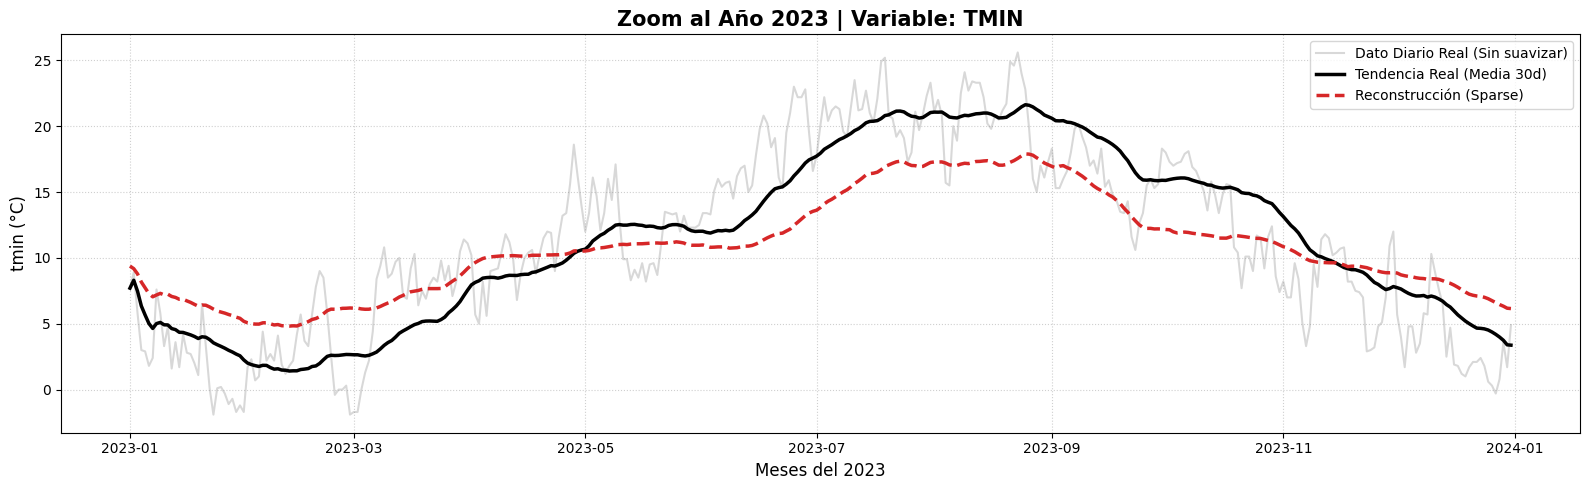

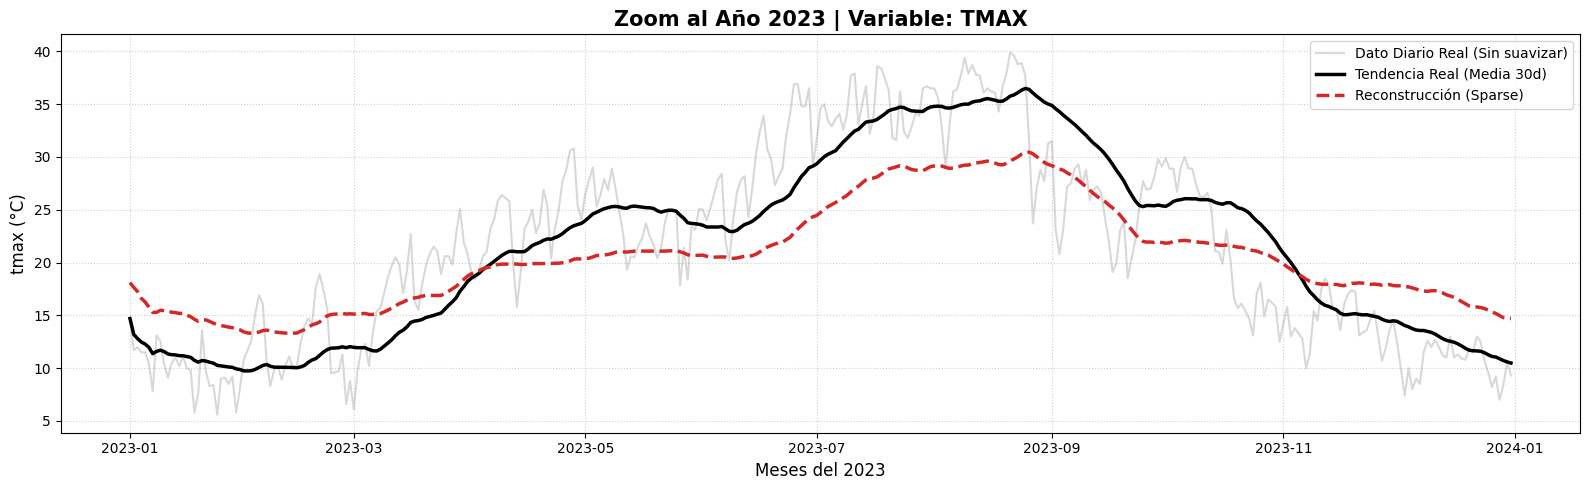

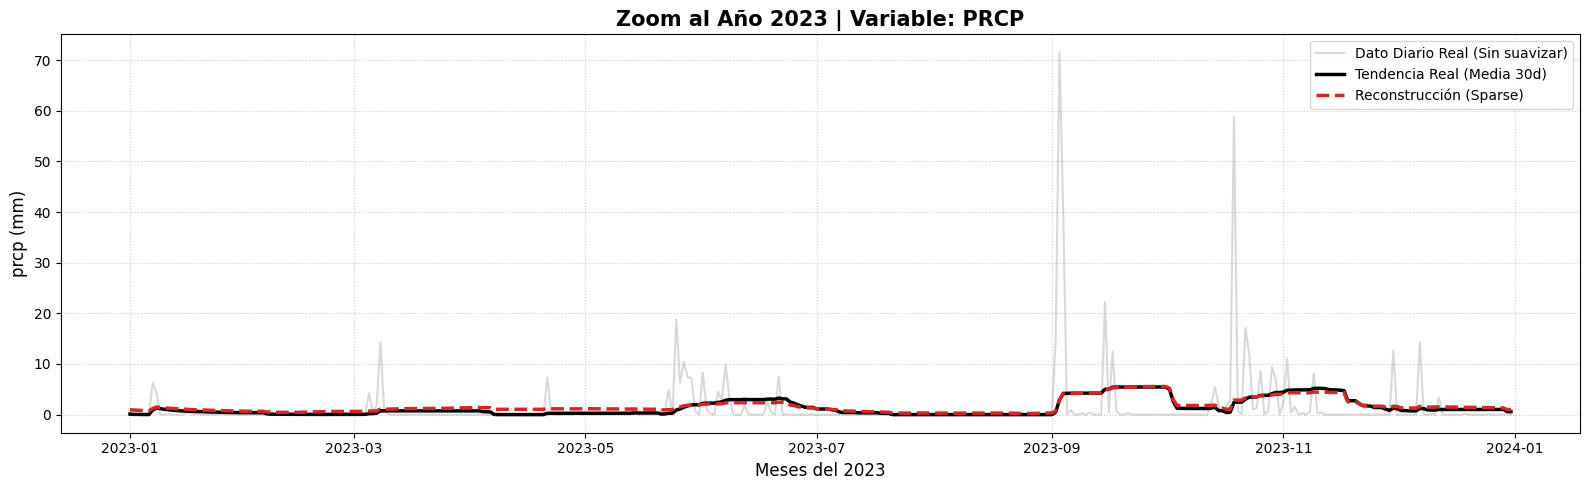

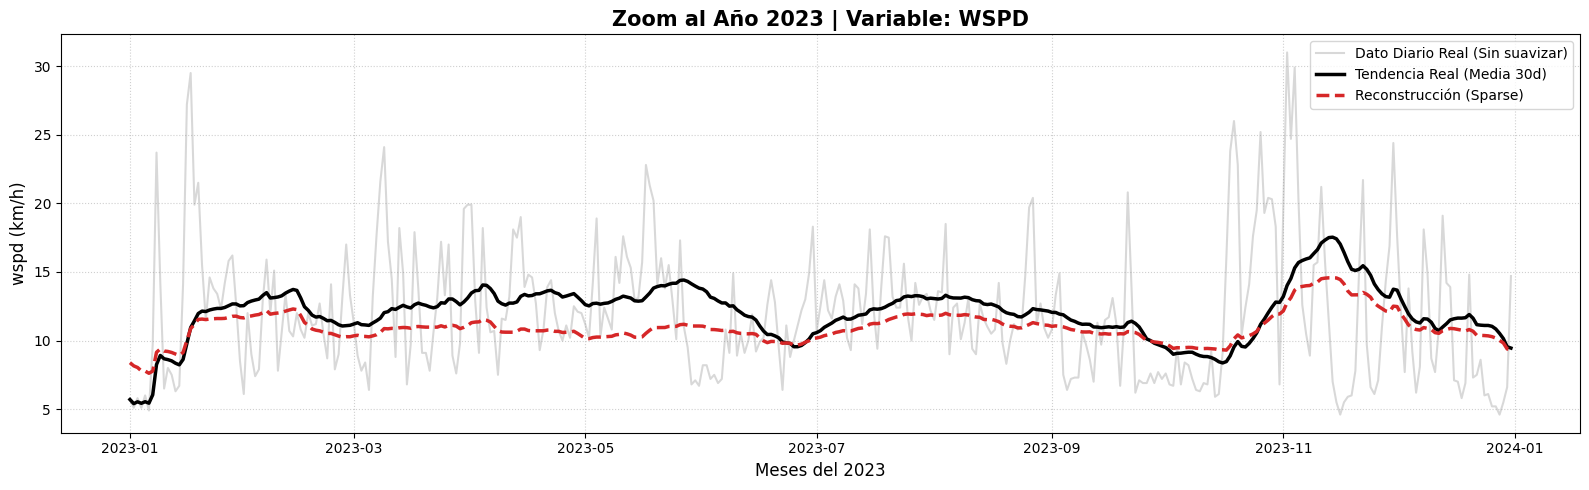

In [49]:
# ==========================================
# 7) ZOOM A UN AÑO ESPECÍFICO DEL TEST
# ==========================================
# ---> CAMBIA ESTE NÚMERO AL AÑO QUE QUIERAS EXPLORAR <---
año_analisis = 2023  

print(f"Generando radiografía detallada para el año {año_analisis}...")

# 1. Deshacemos el escalado de TODA la matriz (Test real y Test reconstruido)
test_real_fisico = scaler.inverse_transform(X_test_scaled)
test_recon_fisico = scaler.inverse_transform(X_test_reconstructed)

# 2. Convertimos todo a DataFrames de Pandas para poder filtrar por fechas fácilmente
fechas_test = X_test_raw.index
df_real = pd.DataFrame(test_real_fisico, index=fechas_test, columns=nombres_variables)
df_recon = pd.DataFrame(test_recon_fisico, index=fechas_test, columns=nombres_variables)

# 3. Filtramos los datos para quedarnos SOLO con el año elegido
try:
    df_real_año = df_real.loc[str(año_analisis)]
    df_recon_año = df_recon.loc[str(año_analisis)]
except KeyError:
    print(f"⚠️ Error: El año {año_analisis} no está en el conjunto de prueba.")
    print(f"Prueba con un año entre {fechas_test.year.min()} y {fechas_test.year.max()}")

unidades = {'tavg': '°C', 'tmin': '°C', 'tmax': '°C', 'prcp': 'mm', 'wspd': 'km/h'}

# 4. Bucle para dibujar las 5 gráficas de ese año por separado
for variable in nombres_variables:
    
    # Aislamos la variable actual
    serie_real_año = df_real_año[variable]
    serie_recon_año = df_recon_año[variable]
    
    # Suavizamos los datos. 
    # Usamos min_periods=1 para que no nos deje el mes de enero en blanco al hacer la media
    real_suavizado = serie_real_año.rolling(window=30, min_periods=1).mean()
    recon_suavizado = serie_recon_año.rolling(window=30, min_periods=1).mean()
    
    plt.figure(figsize=(16, 5))
    
    # A) Pintamos el dato diario exacto de fondo (gris claro)
    plt.plot(serie_real_año.index, serie_real_año, color='gray', alpha=0.3, label='Dato Diario Real (Sin suavizar)')
    
    # B) Pintamos las tendencias suavizadas (líneas gruesas)
    plt.plot(real_suavizado.index, real_suavizado, color='black', label='Tendencia Real (Media 30d)', linewidth=2.5)
    plt.plot(recon_suavizado.index, recon_suavizado, color='tab:red', label='Reconstrucción (Sparse)', linestyle='--', linewidth=2.5)
    
    # Formato de la gráfica
    unidad = unidades.get(variable, 'Valor')
    plt.title(f'Zoom al Año {año_analisis} | Variable: {variable.upper()}', fontsize=15, fontweight='bold')
    plt.ylabel(f'{variable} ({unidad})', fontsize=12)
    plt.xlabel(f'Meses del {año_analisis}', fontsize=12)
    plt.legend(loc="upper right")
    plt.grid(True, linestyle=':', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

In [53]:
import time
import numpy as np
import pandas as pd
from sklearn.decomposition import DictionaryLearning
from sklearn.metrics import mean_squared_error

# ==========================================
# ENTRENAMIENTO DUAL: 40 vs 200 ÁTOMOS (Baja Penalización L1)
# ==========================================
# Bajamos el alpha a 0.1 para liberar a los modelos del exceso de ceros
alpha_bajo = 0.5  

print("Iniciando el entrenamiento dual... (Usando todos los núcleos al 100%)")

# ---------------------------------------------------------
# MODELO 1: 40 ÁTOMOS (Estructural)
# ---------------------------------------------------------
print("\nEntrenando Modelo 1: 40 Átomos...")
inicio_40 = time.time()

dict_40 = DictionaryLearning(
    n_components=40, 
    alpha=alpha_bajo, 
    transform_algorithm='lasso_lars', 
    random_state=42, 
    max_iter=1000,
    n_jobs=-1  # Máxima potencia
)
dict_40.fit(X_train_scaled)

# Evaluamos el modelo 1 con la década de test
sparse_test_40 = dict_40.transform(X_test_scaled)
recon_40 = np.dot(sparse_test_40, dict_40.components_)
tiempo_40 = time.time() - inicio_40

# Calculamos soluciones exactas
mse_40 = mean_squared_error(X_test_scaled, recon_40)
esparcidad_40 = (np.sum(np.abs(sparse_test_40) < 1e-5) / sparse_test_40.size) * 100

# ---------------------------------------------------------
# MODELO 2: 200 ÁTOMOS (Alta Resolución)
# ---------------------------------------------------------
print("Entrenando Modelo 2: 200 Átomos (Esto requerirá máxima potencia)...")
inicio_200 = time.time()

dict_200 = DictionaryLearning(
    n_components=200, 
    alpha=alpha_bajo, 
    transform_algorithm='lasso_lars', 
    random_state=42, 
    max_iter=1000,
    n_jobs=-1  # Máxima potencia
)
dict_200.fit(X_train_scaled)

# Evaluamos el modelo 2 con la década de test
sparse_test_200 = dict_200.transform(X_test_scaled)
recon_200 = np.dot(sparse_test_200, dict_200.components_)
tiempo_200 = time.time() - inicio_200

# Calculamos soluciones exactas
mse_200 = mean_squared_error(X_test_scaled, recon_200)
esparcidad_200 = (np.sum(np.abs(sparse_test_200) < 1e-5) / sparse_test_200.size) * 100

# ==========================================
# RESULTADOS EXACTOS Y COMPARATIVA
# ==========================================
datos_comparativos = {
    'Métrica': ['MSE (Error Exacto)', 'Esparcidad (% de ceros)', 'Tiempo de CPU'],
    '40 Átomos (alpha=0.1)': [f"{mse_40:.4f}", f"{esparcidad_40:.1f}%", f"{tiempo_40:.2f}s"],
    '200 Átomos (alpha=0.1)': [f"{mse_200:.4f}", f"{esparcidad_200:.1f}%", f"{tiempo_200:.2f}s"]
}

df_comparativa = pd.DataFrame(datos_comparativos)

print("\n" + "="*70)
print("   RADIOGRAFÍA DEL RENDIMIENTO: ALPHA BAJO (0.1)")
print("="*70)
print(df_comparativa.to_string(index=False))
print("="*70)

Iniciando el entrenamiento dual... (Usando todos los núcleos al 100%)

Entrenando Modelo 1: 40 Átomos...
Entrenando Modelo 2: 200 Átomos (Esto requerirá máxima potencia)...

   RADIOGRAFÍA DEL RENDIMIENTO: ALPHA BAJO (0.1)
                Métrica 40 Átomos (alpha=0.1) 200 Átomos (alpha=0.1)
     MSE (Error Exacto)                0.0595                 0.0536
Esparcidad (% de ceros)                 94.1%                  98.5%
          Tiempo de CPU                72.26s                204.56s
